In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")
print("torch", torch.__version__, "device", device)

torch 2.11.0+cpu device cpu


In [14]:
N_BATCH = 5000
X_MIN, X_MAX = -2*np.pi, 2*np.pi
LR = 1e-3

def target(x):
    return torch.sin(x) + torch.sin(5.0 * x)

x_train = (X_MIN + (X_MAX - X_MIN) * torch.rand(N_BATCH, 1)).to(device)
y_train = target(x_train)

x_plot = torch.linspace(X_MIN, X_MAX, 1000).unsqueeze(1).to(device)
y_plot = target(x_plot)
y_low = torch.sin(x_plot)

print("x_train", tuple(x_train.shape), "y_train", tuple(y_train.shape))
print("x_plot ", tuple(x_plot.shape))


x_train (5000, 1) y_train (5000, 1)
x_plot  (1000, 1)


In [15]:
class MLP(nn.Module):
    """Полносвязная сеть: 1 -> 256 -> 256 -> 1, tanh на скрытых слоях."""

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 1)
        self.act = nn.Tanh()

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1))
        out = self.fc3(h2)
        return out

model_mlp = MLP().to(device)
print(model_mlp)

with torch.no_grad():
    h1 = model_mlp.act(model_mlp.fc1(x_train))
    h2 = model_mlp.act(model_mlp.fc2(h1))
    out = model_mlp.fc3(h2)
print("fc1 output.shape", tuple(h1.shape))
print("fc2 output.shape", tuple(h2.shape))
print("fc3 output.shape", tuple(out.shape))


MLP(
  (fc1): Linear(in_features=1, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1, bias=True)
  (act): Tanh()
)
fc1 output.shape (5000, 256)
fc2 output.shape (5000, 256)
fc3 output.shape (5000, 1)


MLP: loss после 3000 эпох = 7.776658e-03


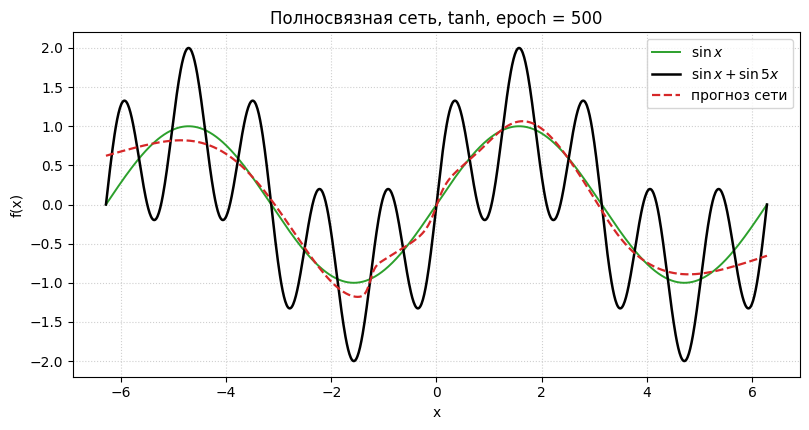

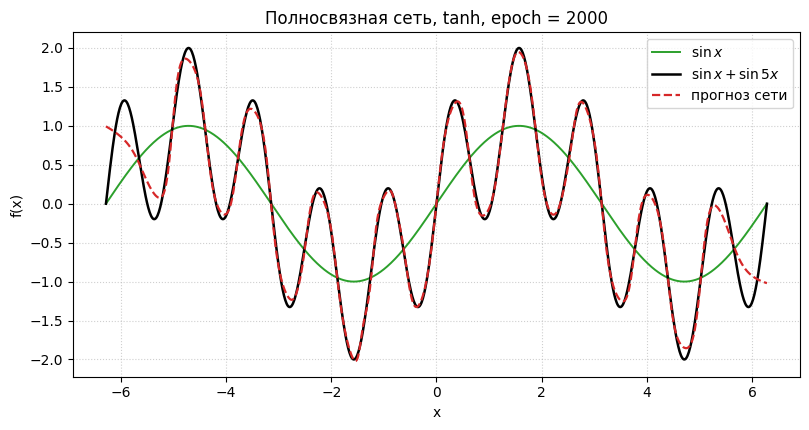

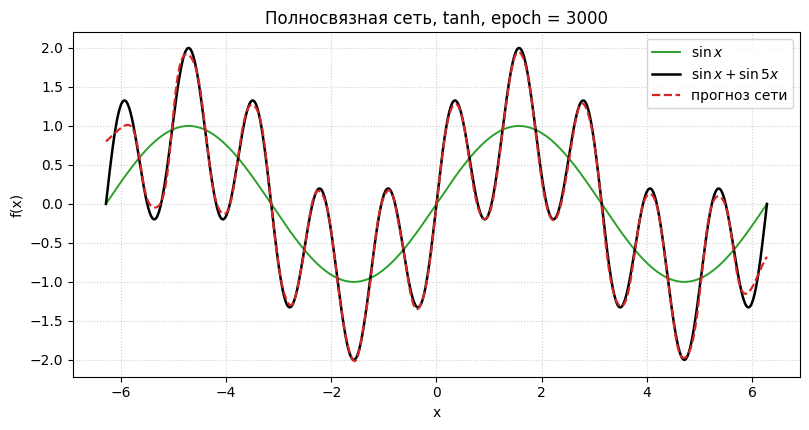

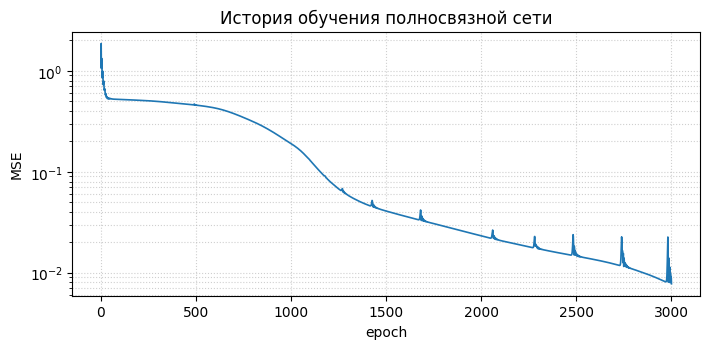

In [16]:
def train(model, n_epochs, x, y, lr=LR, snapshot_epochs=()):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []
    snapshots = {}
    for epoch in range(1, n_epochs + 1):
        model.train()
        opt.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        history.append(float(loss.detach()))
        if epoch in snapshot_epochs:
            model.eval()
            with torch.no_grad():
                snapshots[epoch] = model(x_plot).cpu().numpy().ravel()
    return history, snapshots


def plot_fit(epoch, pred, title):
    xp = x_plot.cpu().numpy().ravel()
    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    ax.plot(xp, y_low.cpu().numpy().ravel(), color="tab:green", lw=1.4, label=r"$\sin x$")
    ax.plot(xp, y_plot.cpu().numpy().ravel(), color="black", lw=1.8, label=r"$\sin x + \sin 5x$")
    ax.plot(xp, pred, color="tab:red", lw=1.6, ls="--", label="прогноз сети")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.set_title(title + f", epoch = {epoch}")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    fig.tight_layout()
    plt.show()


torch.manual_seed(0)
model_mlp = MLP().to(device)
hist_mlp, snaps_mlp = train(
    model_mlp, n_epochs=3000, x=x_train, y=y_train,
    snapshot_epochs=(500, 2000, 3000),
)
print(f"MLP: loss после 3000 эпох = {hist_mlp[-1]:.6e}")

for epoch in (500, 2000, 3000):
    plot_fit(epoch, snaps_mlp[epoch], "Полносвязная сеть, tanh")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.semilogy(np.arange(1, len(hist_mlp) + 1), hist_mlp, lw=1.2)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("История обучения полносвязной сети")
ax.grid(True, which="both", ls=":", alpha=0.6)
fig.tight_layout()
plt.show()


In [17]:
class FourierFeatureEmbedding(nn.Module):
    """Слой Фурье-кодирования из лекции.

    B фиксируется и не обучается. Выход имеет размер 2 * mapping_size.
    """

    def __init__(self, in_dim, mapping_size, scale=10.0):
        super().__init__()
        B = torch.randn(in_dim, mapping_size) * scale * 2 * torch.pi
        self.register_buffer("B", B)

    def forward(self, v):
        proj = torch.matmul(v, self.B)
        return torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)

class FourierNet(nn.Module):
    """Фурье-кодирование и один промежуточный слой на 256 нейронов."""

    def __init__(self, in_dim=1, mapping_size=128, scale=10.0, use_activation=True):
        super().__init__()
        self.fourier_embedding = FourierFeatureEmbedding(in_dim, mapping_size, scale)
        self.hidden = nn.Linear(2 * mapping_size, 256)
        self.out = nn.Linear(256, 1)
        self.use_activation = use_activation
        self.act = nn.Tanh()

    def forward(self, x):
        gamma = self.fourier_embedding(x)          # (N, 256)
        h = self.hidden(gamma)                     # (N, 256)
        if self.use_activation:
            h = self.act(h)
        return self.out(h)                         # (N, 1)


torch.manual_seed(0)
model_ff = FourierNet(in_dim=1, mapping_size=128, scale=10.0, use_activation=True).to(device)
print(model_ff)

with torch.no_grad():
    gamma = model_ff.fourier_embedding(x_train)
    h = model_ff.act(model_ff.hidden(gamma))
    out = model_ff.out(h)
print("fourier output.shape", tuple(gamma.shape))
print("hidden  output.shape", tuple(h.shape))
print("out     output.shape", tuple(out.shape))
print("B.shape", tuple(model_ff.fourier_embedding.B.shape),
      "B.requires_grad", model_ff.fourier_embedding.B.requires_grad)


FourierNet(
  (fourier_embedding): FourierFeatureEmbedding()
  (hidden): Linear(in_features=256, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=1, bias=True)
  (act): Tanh()
)
fourier output.shape (5000, 256)
hidden  output.shape (5000, 256)
out     output.shape (5000, 1)
B.shape (1, 128) B.requires_grad False


Fourier + tanh: loss после 200 эпох = 3.922009e-05


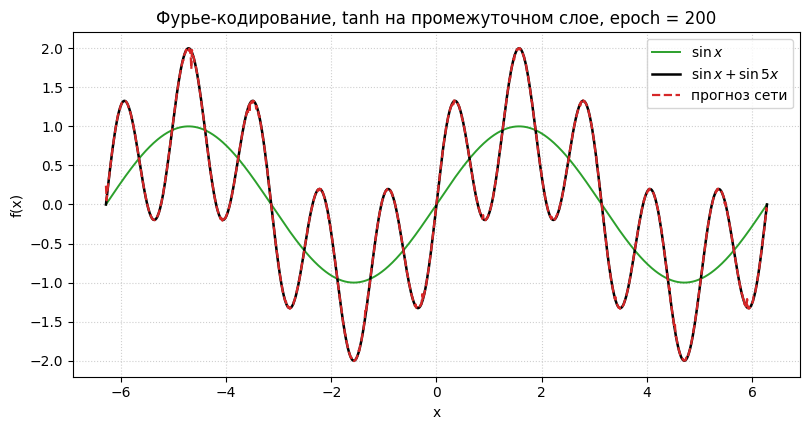

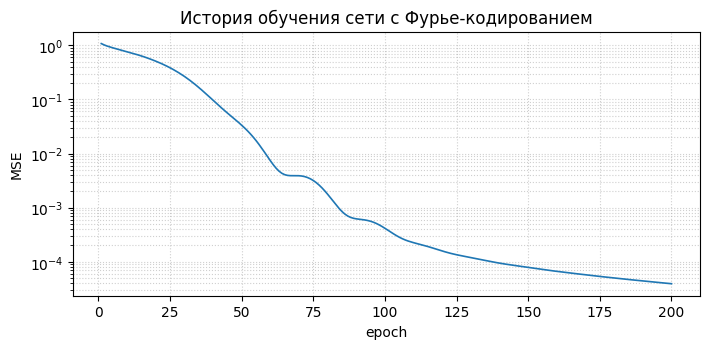

In [18]:
torch.manual_seed(1)
model_ff = FourierNet(mapping_size=128, scale=10.0, use_activation=True).to(device)
hist_ff, snaps_ff = train(
    model_ff, n_epochs=200, x=x_train, y=y_train, snapshot_epochs=(200,)
)
print(f"Fourier + tanh: loss после 200 эпох = {hist_ff[-1]:.6e}")
plot_fit(200, snaps_ff[200], "Фурье-кодирование, tanh на промежуточном слое")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.semilogy(np.arange(1, len(hist_ff) + 1), hist_ff, lw=1.2)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("История обучения сети с Фурье-кодированием")
ax.grid(True, which="both", ls=":", alpha=0.6)
fig.tight_layout()
plt.show()

FourierNet(
  (fourier_embedding): FourierFeatureEmbedding()
  (hidden): Linear(in_features=256, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=1, bias=True)
  (act): Tanh()
)
Fourier без активаций: loss после 200 эпох = 2.639455e-01


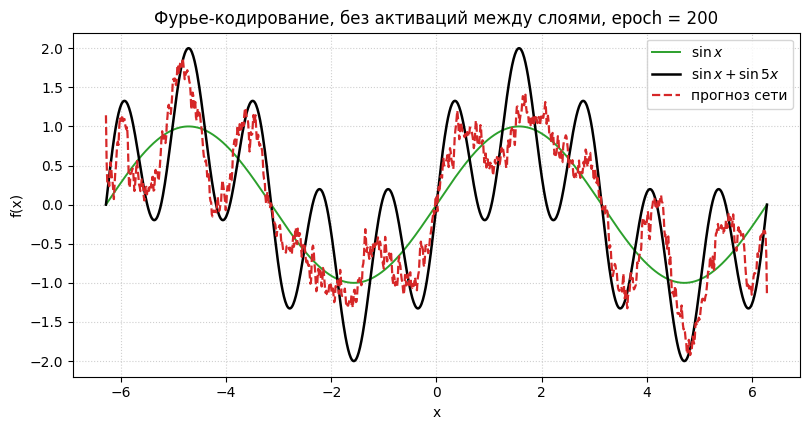

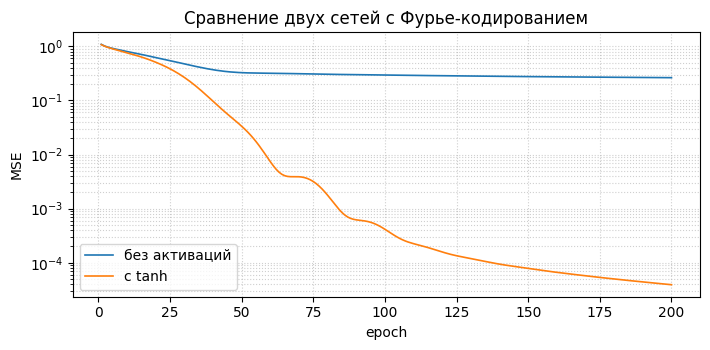

In [19]:
torch.manual_seed(1)
model_lin = FourierNet(mapping_size=128, scale=10.0, use_activation=False).to(device)
print(model_lin)



hist_lin, snaps_lin = train(
    model_lin, n_epochs=200, x=x_train, y=y_train, snapshot_epochs=(200,)
)
print(f"Fourier без активаций: loss после 200 эпох = {hist_lin[-1]:.6e}")
plot_fit(200, snaps_lin[200], "Фурье-кодирование, без активаций между слоями")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.semilogy(np.arange(1, len(hist_lin) + 1), hist_lin, lw=1.2, label="без активаций")
ax.semilogy(np.arange(1, len(hist_ff) + 1), hist_ff, lw=1.2, label="с tanh")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("Сравнение двух сетей с Фурье-кодированием")
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.legend()
fig.tight_layout()
plt.show()
